<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day3_ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [6]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [8]:

# Extraction du zip
ZIP_PATH = 'Heart_Disease_Prediction_Dataset.zip'
EXTRACT_DIR = 'heart_ds'
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# Liste des CSV et chargement
csv_path = os.path.join(EXTRACT_DIR, 'dataset_heart.csv')
df = pd.read_csv(csv_path)

# Inspection
print("Shape :", df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))

# Colonne cible : s'appelle 'heart disease' (pas 'target') dans ce dataset
# Valeurs : 1 = sain, 2 = malade → on binarise en 0/1
target = 'heart disease'
df[target] = df[target].map({1: 0, 2: 1})
print("\nDistribution cible :", df[target].value_counts().to_dict())

# Séparation features / cible
X = df.drop(columns=[target])
y = df[target]

# Train/test split avec stratification pour conserver la proportion de malades
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nX_train : {X_train.shape} | X_test : {X_test.shape}")


Shape : (270, 14)


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
heart disease                             int64
dtype: object
Missing per column:


,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0



Distribution cible : {0: 150, 1: 120}

X_train : (216, 13) | X_test : (54, 13)


### Basic visual checks

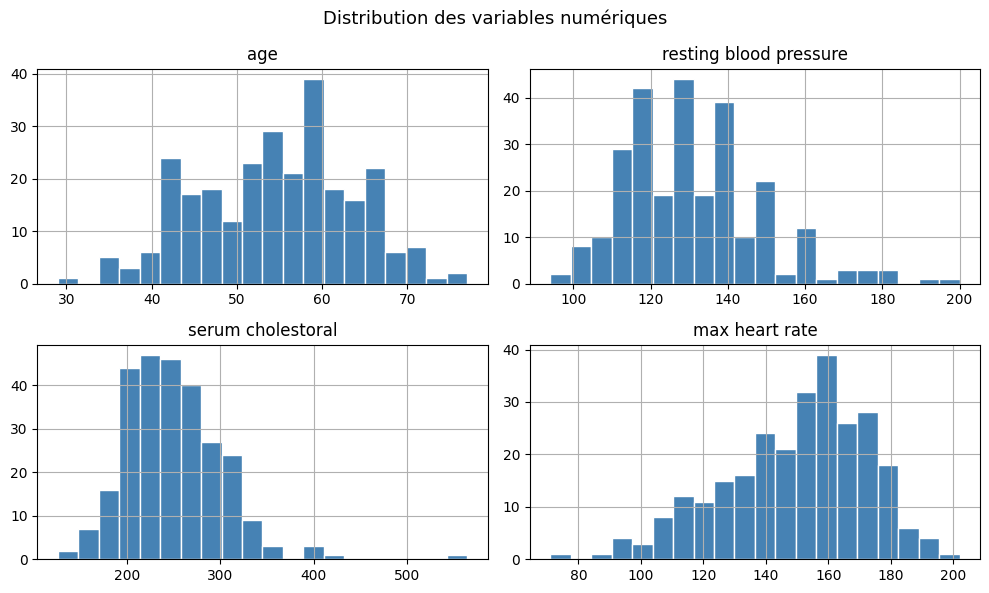

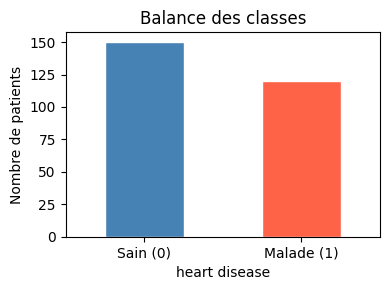

In [9]:
# TODO: pick a few numeric columns and plot histograms
# TODO: plot class balance as a bar chart


# Histogrammes de quelques colonnes numériques clés
num_preview = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate']
df[num_preview].hist(figsize=(10, 6), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribution des variables numériques', fontsize=13)
plt.tight_layout()
plt.show()

# Équilibre des classes (balance)
fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().sort_index().plot(kind='bar', color=['steelblue', 'tomato'],
                                    edgecolor='white', ax=ax)
ax.set_xticklabels(['Sain (0)', 'Malade (1)'], rotation=0)
ax.set_title('Balance des classes')
ax.set_ylabel('Nombre de patients')
plt.tight_layout()
plt.show()



## Preprocessing pipeline

In [10]:

# Détection automatique des colonnes selon leur type
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print("Colonnes catégorielles :", cat_cols)
print("Colonnes numériques    :", num_cols)

# ColumnTransformer : StandardScaler sur les numériques, OneHotEncoder sur les catégorielles
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])




Colonnes catégorielles : []
Colonnes numériques    : ['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']


## Helper - evaluation function

Logistic Regression (no GridSearch) {'accuracy': 0.8519, 'precision': 0.7857, 'recall': 0.9167, 'f1': 0.8462}


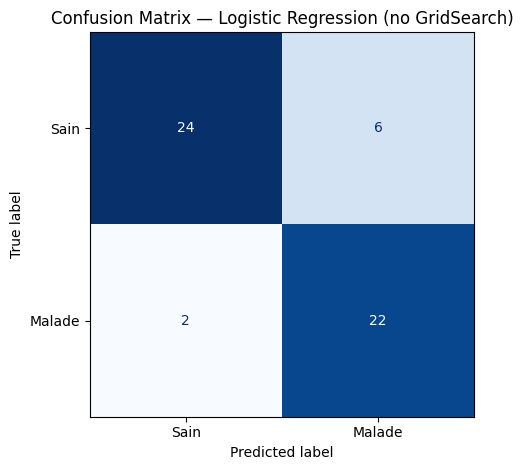

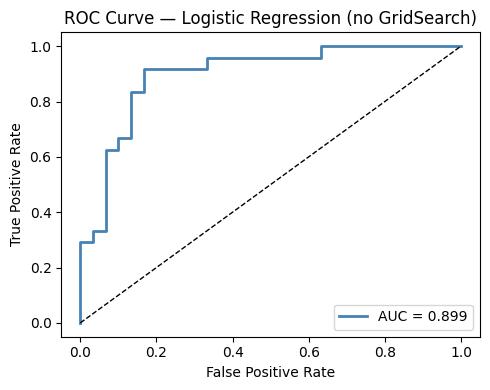

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Redéfinition de pre
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Redéfinition de eval_and_report
def eval_and_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
    }
    print(name, {k: round(v, 4) for k, v in metrics.items()})
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Sain', 'Malade']).plot(cmap='Blues', colorbar=False)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout(); plt.show()
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve — {name}'); plt.legend()
        plt.tight_layout(); plt.show()
    return metrics

# Pipeline + entraînement
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)

# Évaluation
lr_no_gs_metrics = eval_and_report("Logistic Regression (no GridSearch)", pipe_lr, X_test, y_test)

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (no GridSearch) {'accuracy': 0.8519, 'precision': 0.7857, 'recall': 0.9167, 'f1': 0.8462}


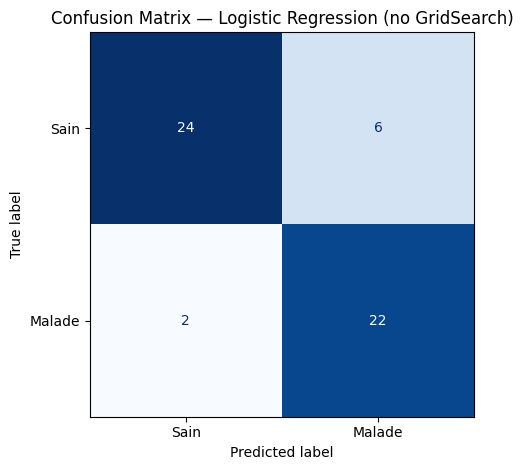

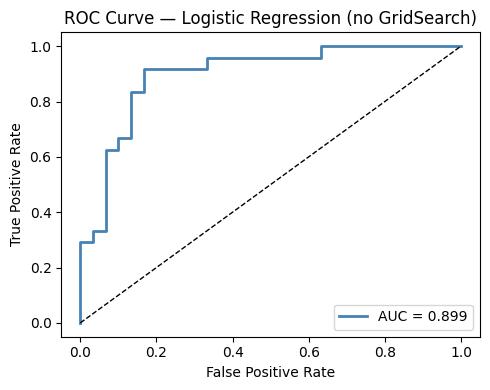

In [15]:
# Création du pipeline : prétraitement + modèle de régression logistique
# solver='liblinear' : optimiseur adapté aux petits datasets comme celui-ci
# max_iter=1000 : assez d'itérations pour garantir la convergence
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# Entraînement sur les données d'entraînement
pipe_lr.fit(X_train, y_train)

# Évaluation avec la fonction définie au bloc 4
lr_no_gs_metrics = eval_and_report("Logistic Regression (no GridSearch)", pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'classifier__C': 0.001, 'classifier__penalty': 'l2'}
LR grid {'accuracy': 0.8148, 'precision': 0.7692, 'recall': 0.8333, 'f1': 0.8}


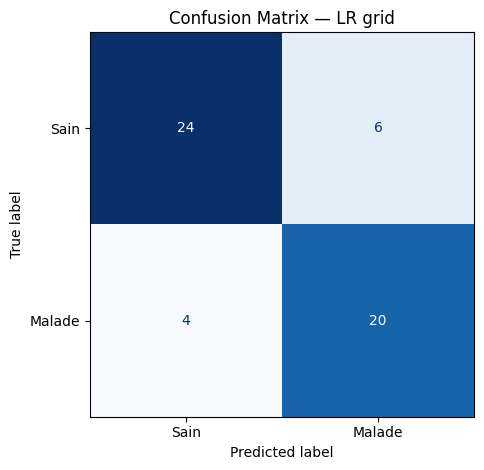

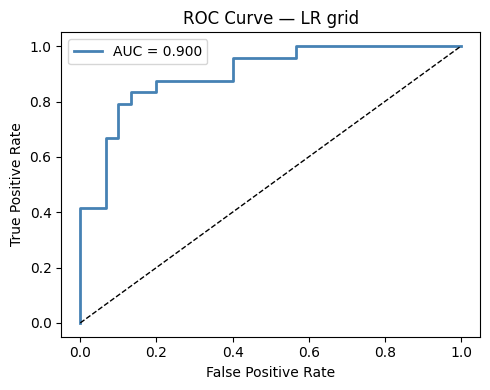

In [26]:
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'] # Added penalty as well, as hinted
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148, 'precision': 0.7692, 'recall': 0.8333, 'f1': 0.8}


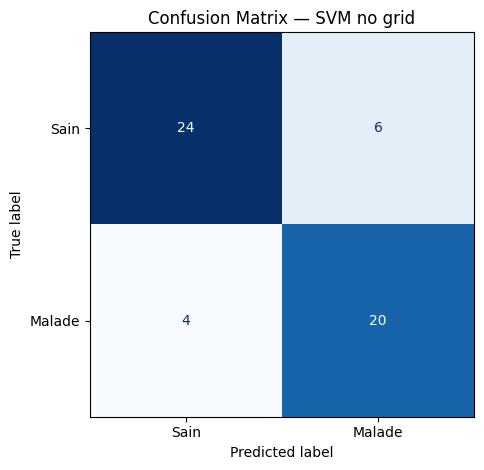

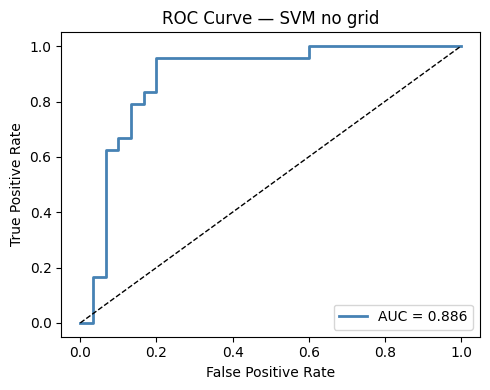

In [19]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale',
                       probability=True, random_state=RANDOM_STATE))
])

pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

# pipe_svm.fit(...)
# svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV F1 : 0.8151
SVM grid {'accuracy': 0.8519, 'precision': 0.8077, 'recall': 0.875, 'f1': 0.84}


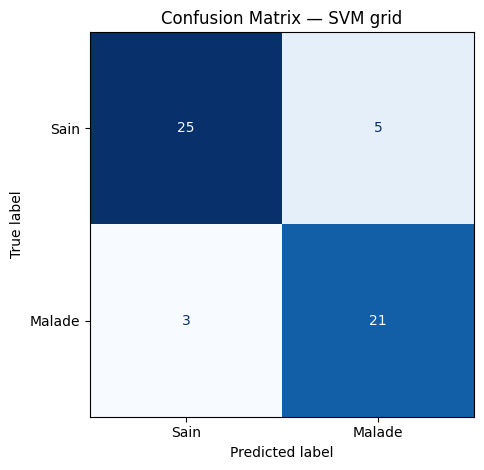

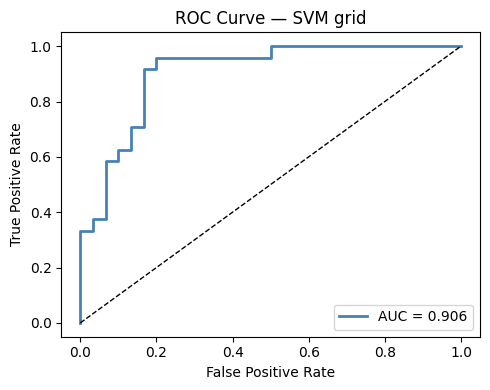

In [20]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C':      [0.1, 1, 10, 100],
    'svm__gamma':  ['scale', 'auto'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
print('Best CV F1 :', round(grid_svm.best_score_, 4))

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)
# best_svm = grid_svm.best_estimator_
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.8333, 'precision': 0.8, 'recall': 0.8333, 'f1': 0.8163}


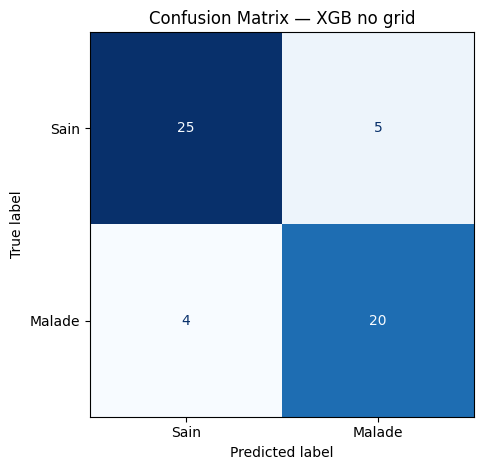

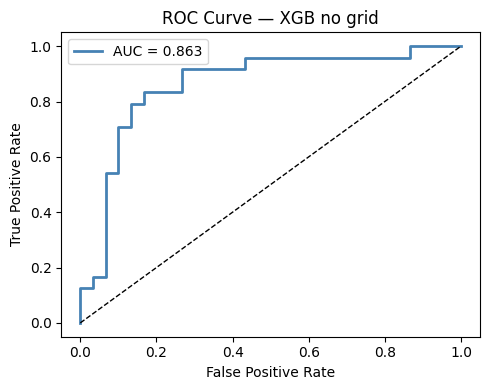

In [21]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb =Pipeline([
    ('preprocessor', pre),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

pipe_xgb.fit(X_train, y_train)

xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
# pipe_xgb.fit(...)
# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
Best CV F1 : 0.8023
XGB grid {'accuracy': 0.7963, 'precision': 0.7407, 'recall': 0.8333, 'f1': 0.7843}


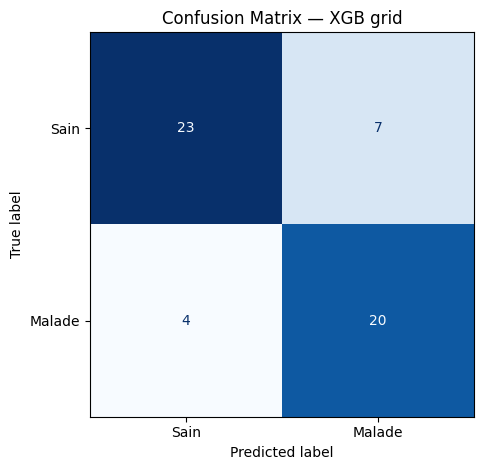

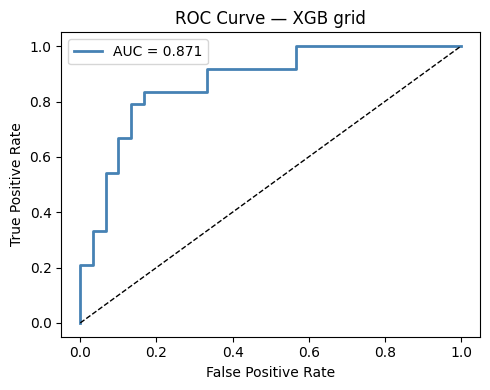

In [22]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv =  Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE))
])
# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators':    [100, 300],
    'xgb__learning_rate':   [0.05, 0.1],
    'xgb__max_depth':       [3, 4, 5],
    'xgb__subsample':       [0.8, 1.0],
    'xgb__colsample_bytree':[0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)
print('Best CV F1 :', round(grid_xgb.best_score_, 4))

best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

# best_xgb = grid_xgb.best_estimator_
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [27]:
import pandas as pd

# Dictionnaire regroupant les métriques de tous les modèles entraînés
summary = {}
summary['LR no grid']  = lr_no_gs_metrics
summary['LR grid']     = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid']    = svm_gs_metrics
summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid']    = xgb_gs_metrics

# Création du DataFrame de comparaison
# orient='index' : chaque clé du dict devient une ligne (un modèle)
df_summary = pd.DataFrame.from_dict(summary, orient='index')
df_summary = df_summary.round(4)

# Mise en valeur du meilleur score par colonne
display(df_summary.style.highlight_max(axis=0, color='lightgreen'))

,accuracy,precision,recall,f1
LR no grid,0.851900,0.785700,0.916700,0.846200
LR grid,0.814800,0.769200,0.833300,0.800000
SVM no grid,0.814800,0.769200,0.833300,0.800000
SVM grid,0.851900,0.807700,0.875000,0.840000
XGB no grid,0.833300,0.800000,0.833300,0.816300
XGB grid,0.796300,0.740700,0.833300,0.784300
